# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Worlds Happiness Dataset](https://www.kaggle.com/datasets/hassanali789/world-happiness-report-2026-official-rankings)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

/kaggle/input/datasets/hassanali789/world-happiness-report-2026-official-rankings/world_happiness_2026.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('world_happiness_2026.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,rank,country,region,score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,generosity,corruption
0,1,Finland,Western Europe,7.764,1.892,1.581,0.952,0.670,0.186,0.498
1,2,Iceland,Western Europe,7.701,1.874,1.611,0.959,0.662,0.269,0.512
2,3,Denmark,Western Europe,7.688,1.887,1.562,0.948,0.665,0.211,0.495
3,4,Costa Rica,Latin America and Caribbean,7.439,1.254,1.421,0.891,0.631,0.178,0.312
4,5,Sweden,Western Europe,7.401,1.878,1.501,0.952,0.658,0.224,0.481


## last Five row

In [4]:
df.tail()

,rank,country,region,score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,generosity,corruption
142,143,Zimbabwe,Sub-Saharan Africa,2.811,0.341,0.621,0.381,0.211,0.091,0.011
143,144,Congo DR,Sub-Saharan Africa,2.761,0.191,0.601,0.311,0.201,0.141,0.011
144,145,South Sudan,Sub-Saharan Africa,2.711,0.251,0.581,0.251,0.181,0.131,0.011
145,146,Rwanda,Sub-Saharan Africa,2.661,0.391,0.701,0.431,0.381,0.201,0.141
146,147,Afghanistan,South Asia,1.446,0.241,0.341,0.361,0.071,0.071,0.011


## Shape of our dataset

In [5]:
df.shape

(147, 10)

## List out all columns

In [6]:
df.columns

Index(['rank', 'country', 'region', 'score', 'gdp_per_capita',
       'social_support', 'healthy_life_expectancy', 'freedom', 'generosity',
       'corruption'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

rank                         int64
country                     object
region                      object
score                      float64
gdp_per_capita             float64
social_support             float64
healthy_life_expectancy    float64
freedom                    float64
generosity                 float64
corruption                 float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   rank                     147 non-null    int64  
 1   country                  147 non-null    object 
 2   region                   147 non-null    object 
 3   score                    147 non-null    float64
 4   gdp_per_capita           147 non-null    float64
 5   social_support           147 non-null    float64
 6   healthy_life_expectancy  147 non-null    float64
 7   freedom                  147 non-null    float64
 8   generosity               147 non-null    float64
 9   corruption               147 non-null    float64
dtypes: float64(7), int64(1), object(2)
memory usage: 11.6+ KB


## Check Null Value

In [9]:
df.isnull().sum()

rank                       0
country                    0
region                     0
score                      0
gdp_per_capita             0
social_support             0
healthy_life_expectancy    0
freedom                    0
generosity                 0
corruption                 0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,rank,score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,generosity,corruption
count,147.000000,147.000000,147.000000,147.000000,147.000000,147.000000,147.000000,147.000000
mean,74.000000,5.205694,1.043095,1.122279,0.694075,0.457673,0.162884,0.161340
std,42.579338,1.393472,0.588589,0.291444,0.212594,0.135096,0.054843,0.135871
min,1.000000,1.446000,0.171000,0.341000,0.251000,0.071000,0.061000,0.011000
25%,37.500000,3.901000,0.471000,0.851000,0.491000,0.371000,0.131000,0.051000
50%,74.000000,5.431000,1.021000,1.181000,0.771000,0.481000,0.161000,0.121000
75%,110.500000,6.291000,1.596000,1.361000,0.881000,0.561000,0.196000,0.246000
max,147.000000,7.764000,2.121000,1.611000,0.961000,0.671000,0.301000,0.512000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

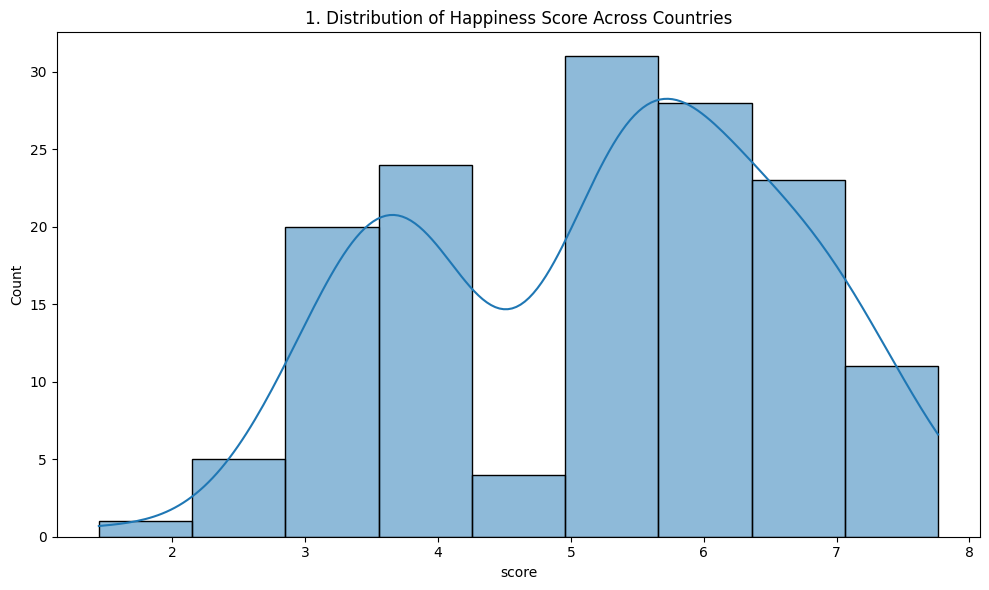

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['score'], kde=True)
plt.title(f'{plot_no}. Distribution of Happiness Score Across Countries')
show_fig()
plot_no += 1

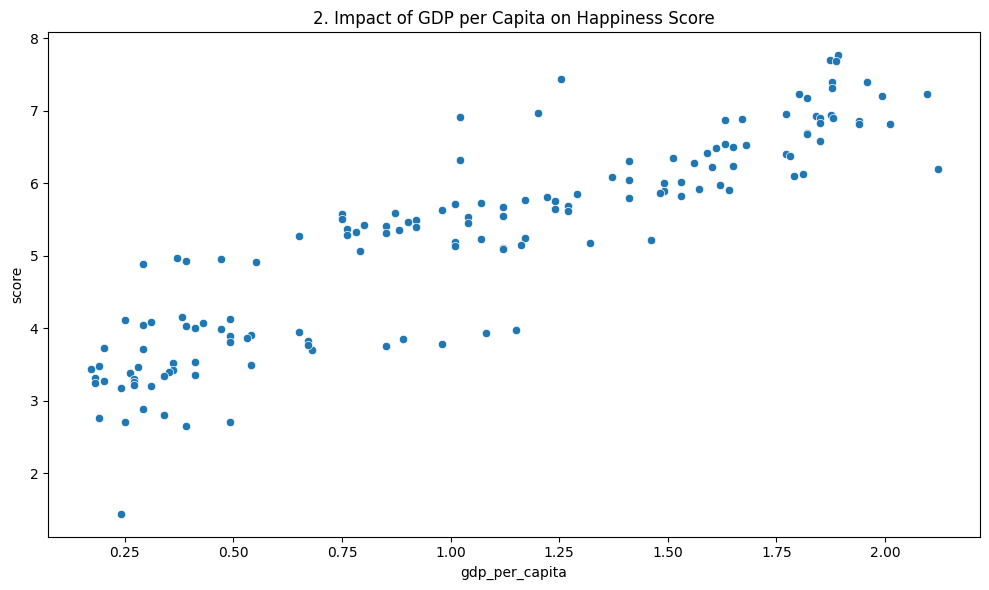

In [14]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='gdp_per_capita', y='score', data=df)
plt.title(f'{plot_no}. Impact of GDP per Capita on Happiness Score')
show_fig()
plot_no += 1

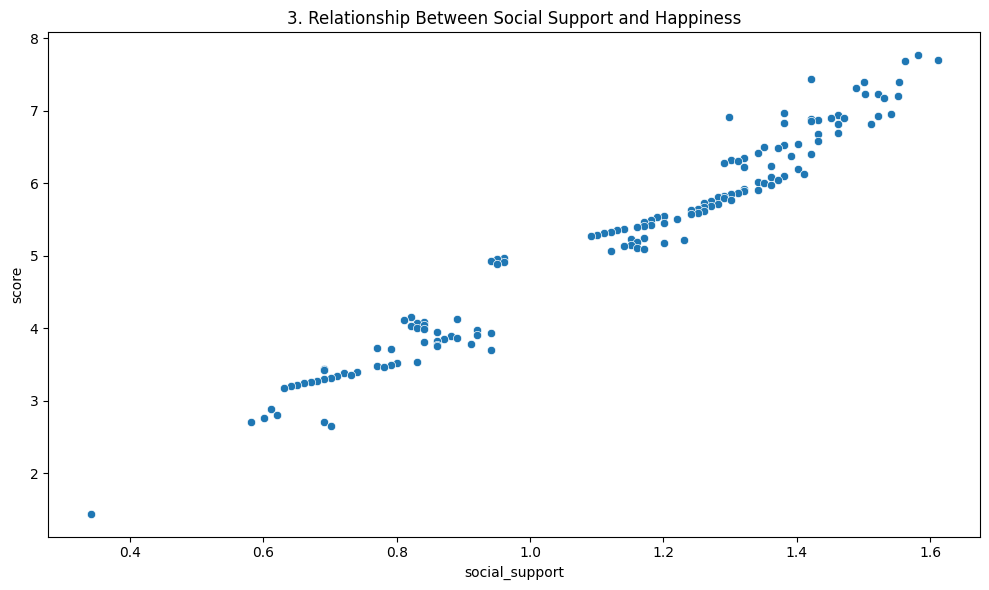

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='social_support', y='score', data=df)
plt.title(f'{plot_no}. Relationship Between Social Support and Happiness')
show_fig()
plot_no += 1

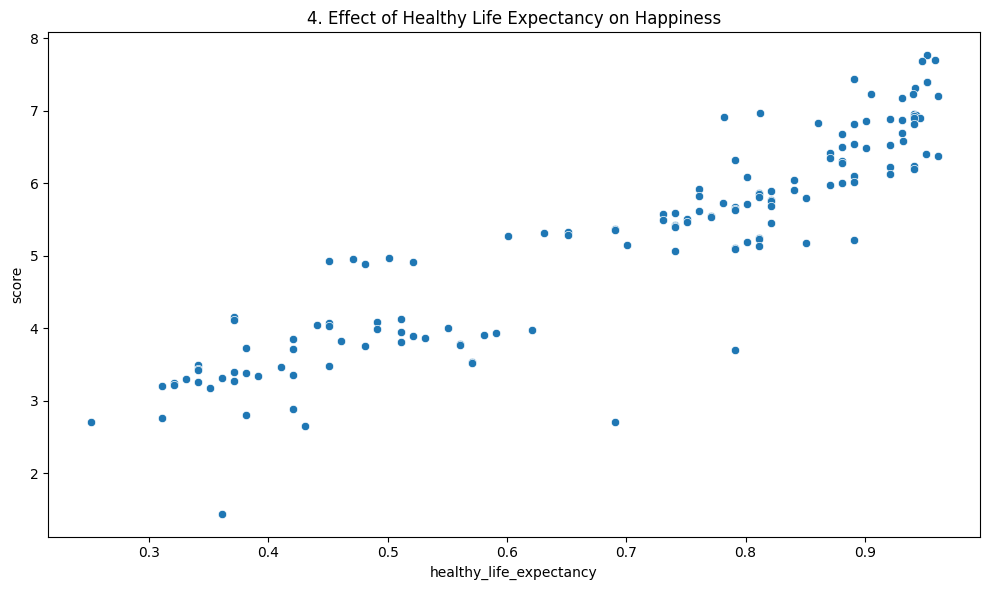

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='healthy_life_expectancy', y='score', data=df)
plt.title(f'{plot_no}. Effect of Healthy Life Expectancy on Happiness')
show_fig()
plot_no += 1

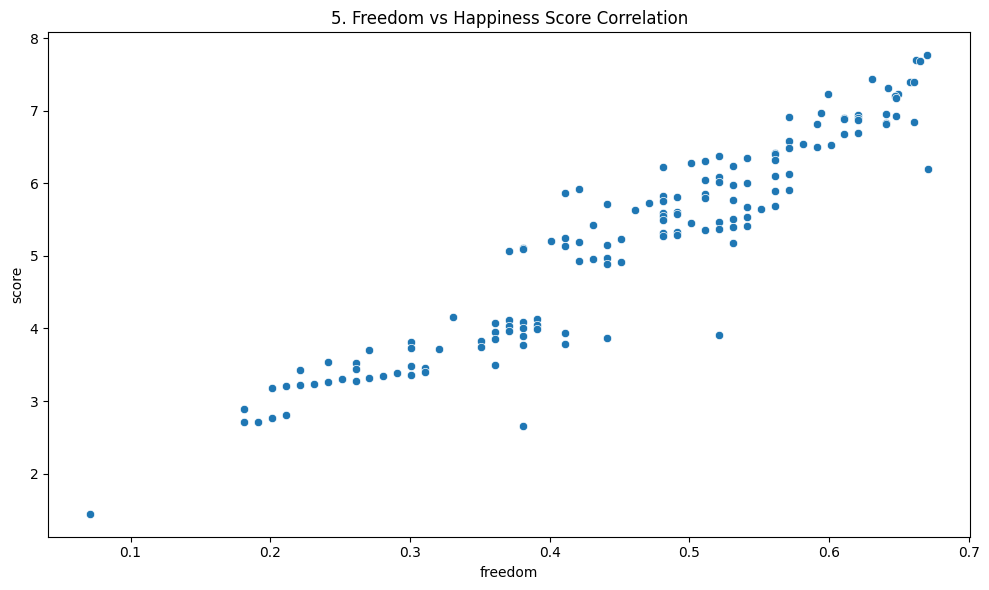

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='freedom', y='score', data=df)
plt.title(f'{plot_no}. Freedom vs Happiness Score Correlation')
show_fig()
plot_no += 1

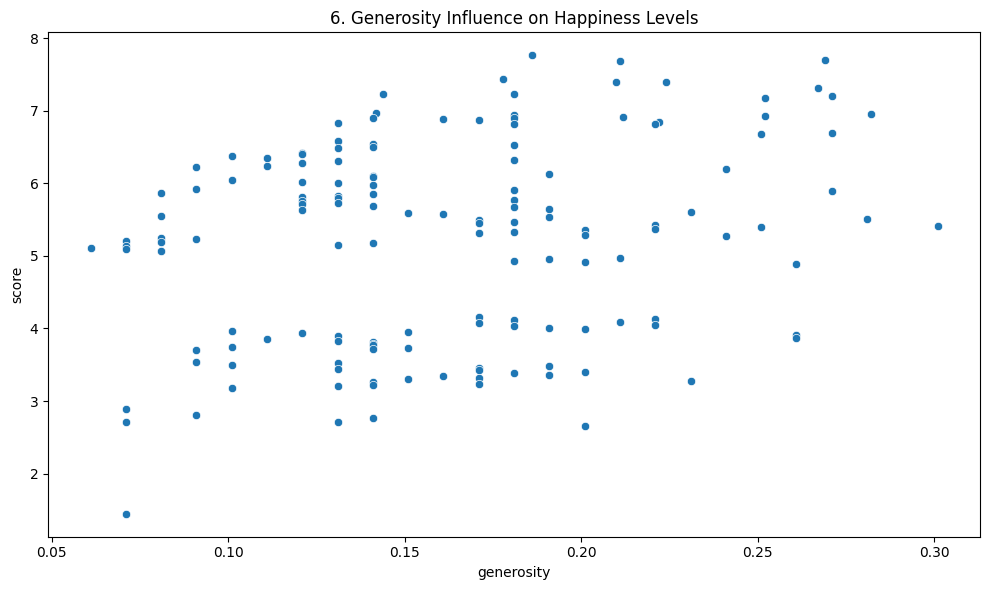

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='generosity', y='score', data=df)
plt.title(f'{plot_no}. Generosity Influence on Happiness Levels')
show_fig()
plot_no += 1

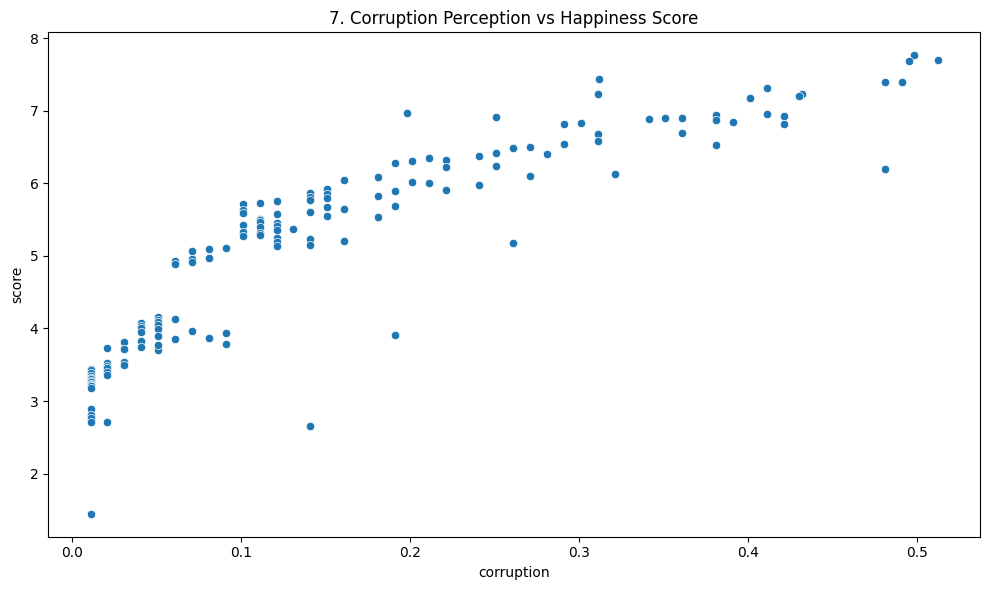

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='corruption', y='score', data=df)
plt.title(f'{plot_no}. Corruption Perception vs Happiness Score')
show_fig()
plot_no += 1

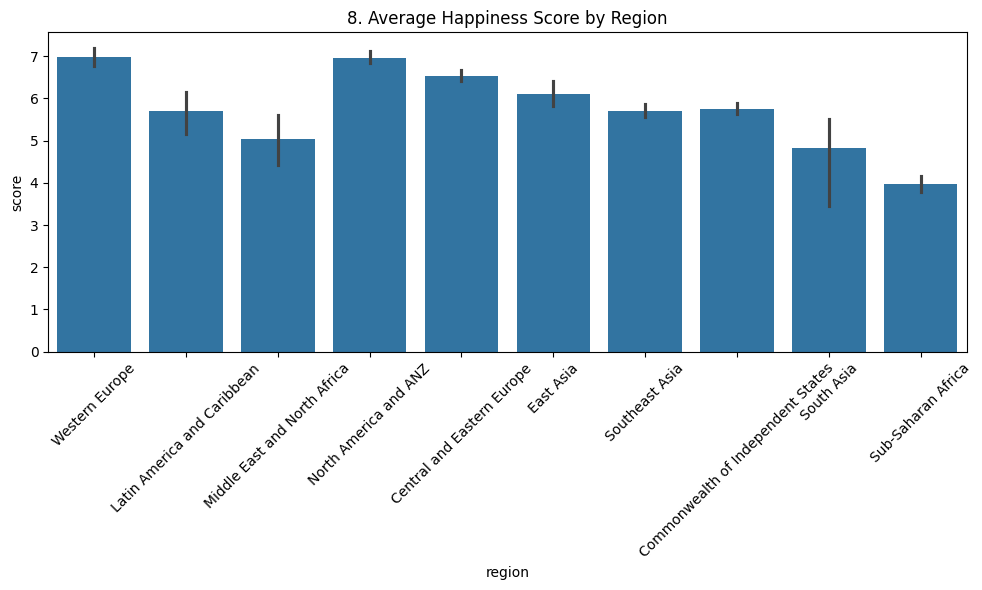

In [20]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='region', y='score', data=df, estimator=np.mean)
plt.title(f'{plot_no}. Average Happiness Score by Region')
plt.xticks(rotation=45)
show_fig()
plot_no += 1

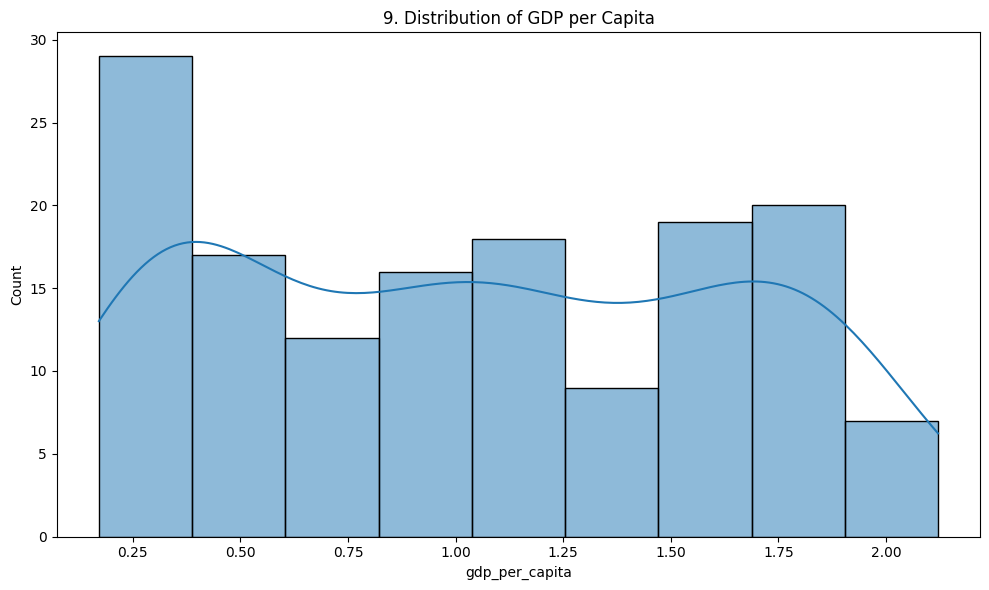

In [21]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['gdp_per_capita'], kde=True)
plt.title(f'{plot_no}. Distribution of GDP per Capita')
show_fig()
plot_no += 1

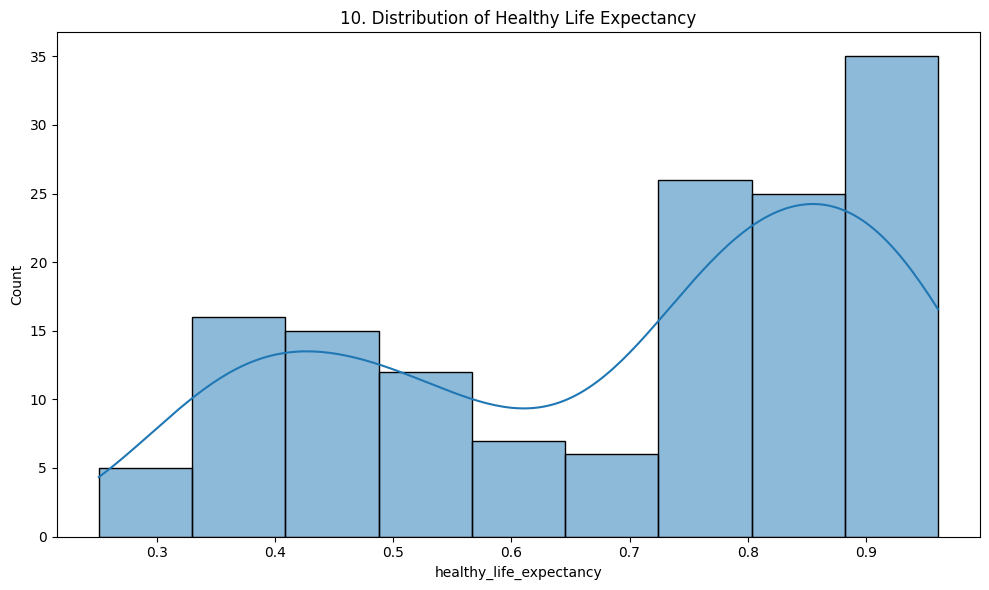

In [22]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['healthy_life_expectancy'], kde=True)
plt.title(f'{plot_no}. Distribution of Healthy Life Expectancy')
show_fig()
plot_no += 1

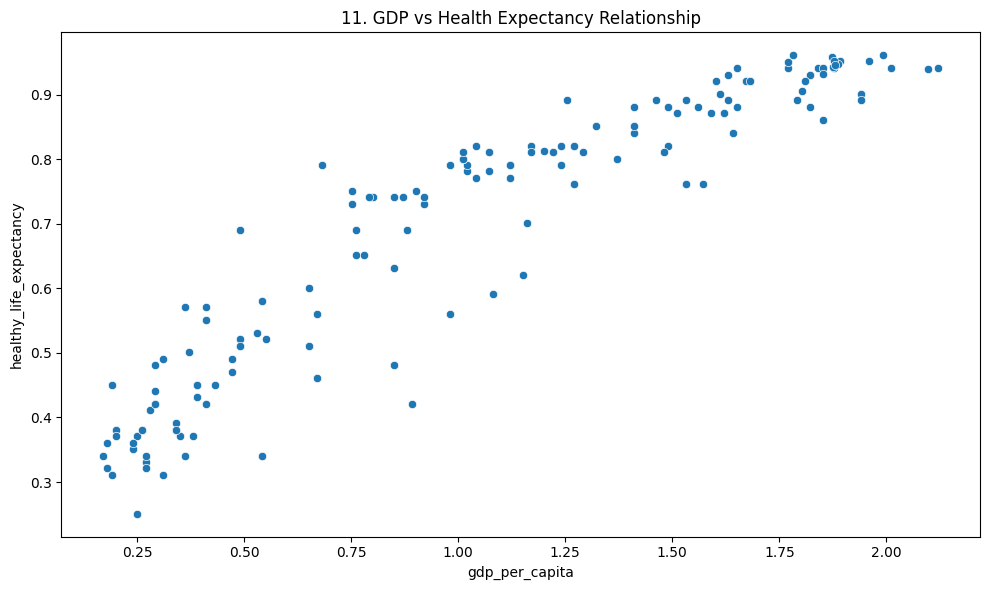

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='gdp_per_capita', y='healthy_life_expectancy', data=df)
plt.title(f'{plot_no}. GDP vs Health Expectancy Relationship')
show_fig()
plot_no += 1

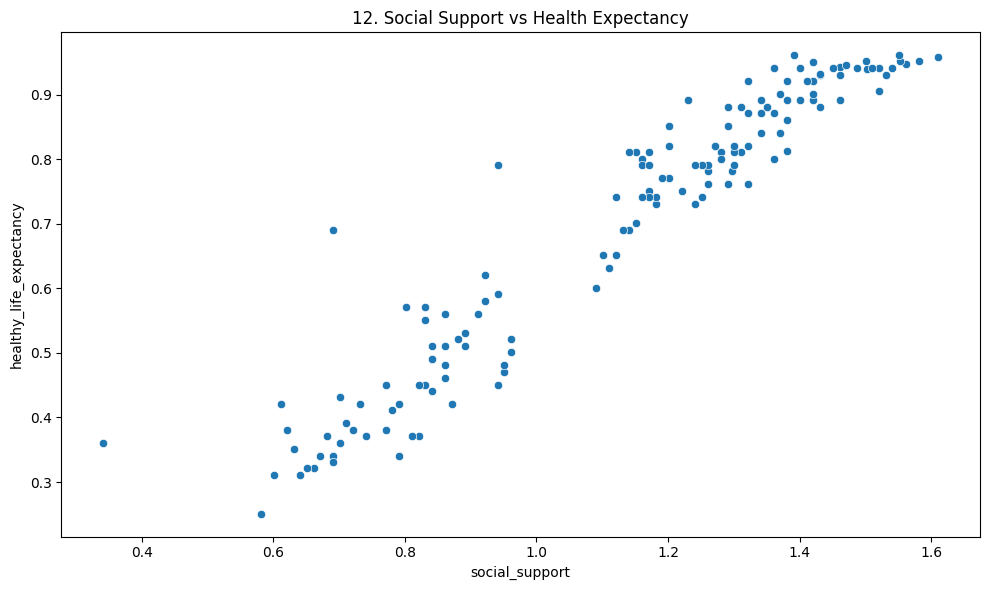

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='social_support', y='healthy_life_expectancy', data=df)
plt.title(f'{plot_no}. Social Support vs Health Expectancy')
show_fig()
plot_no += 1

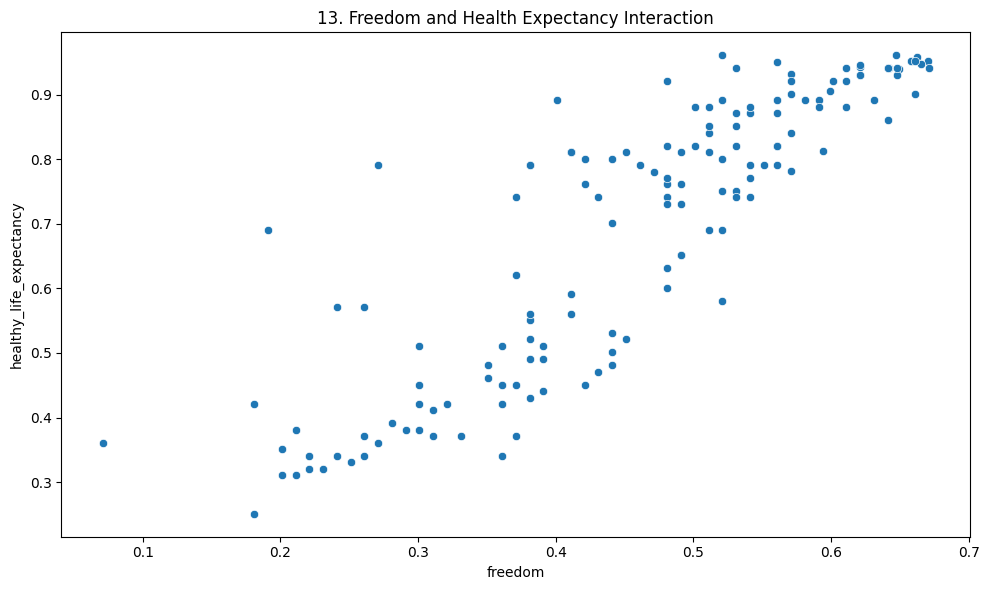

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='freedom', y='healthy_life_expectancy', data=df)
plt.title(f'{plot_no}. Freedom and Health Expectancy Interaction')
show_fig()
plot_no += 1

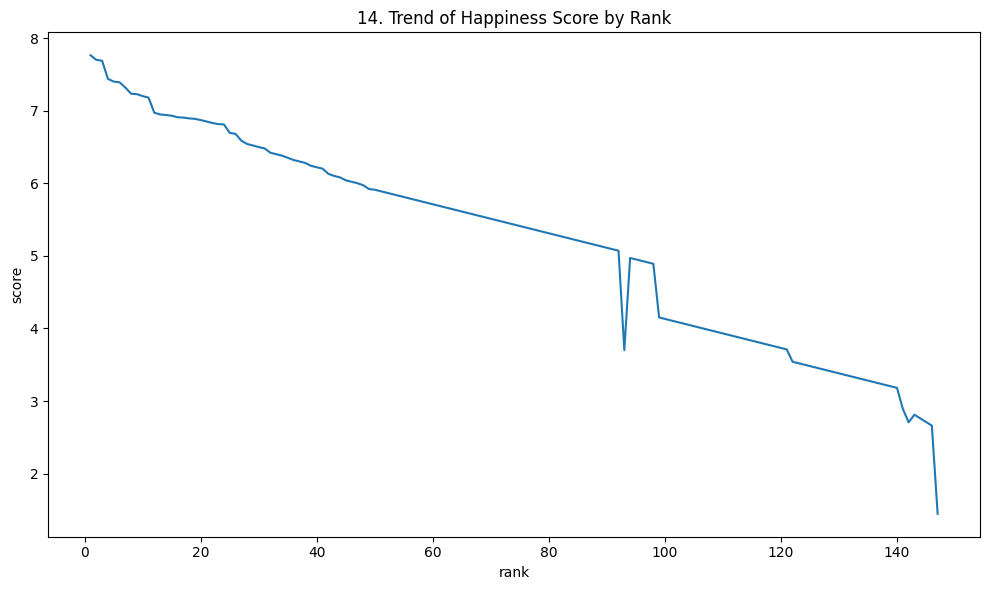

In [26]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(x='rank', y='score', data=df.sort_values('rank'))
plt.title(f'{plot_no}. Trend of Happiness Score by Rank')
show_fig()
plot_no += 1

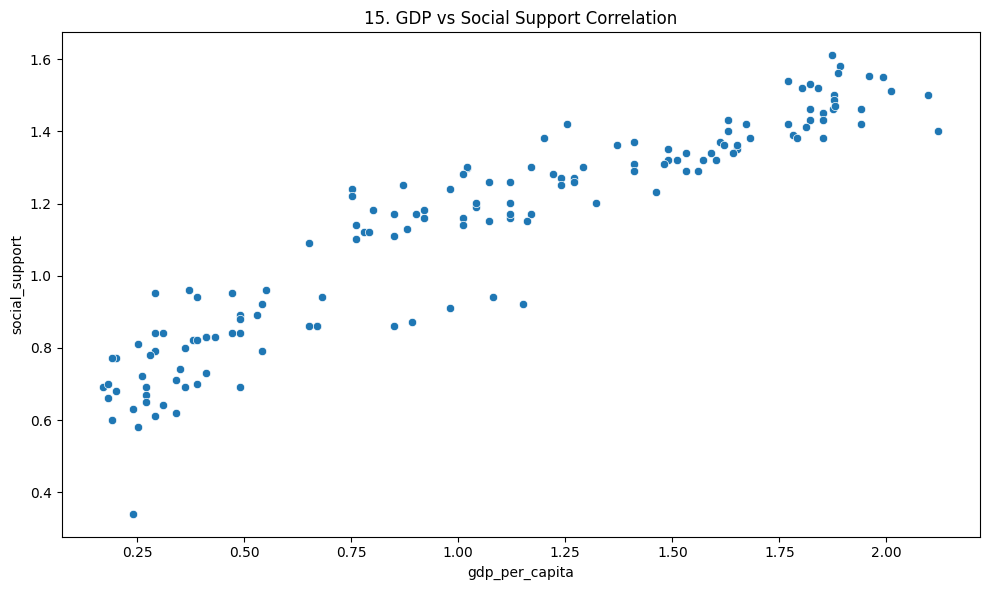

In [27]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='gdp_per_capita', y='social_support', data=df)
plt.title(f'{plot_no}. GDP vs Social Support Correlation')
show_fig()
plot_no += 1

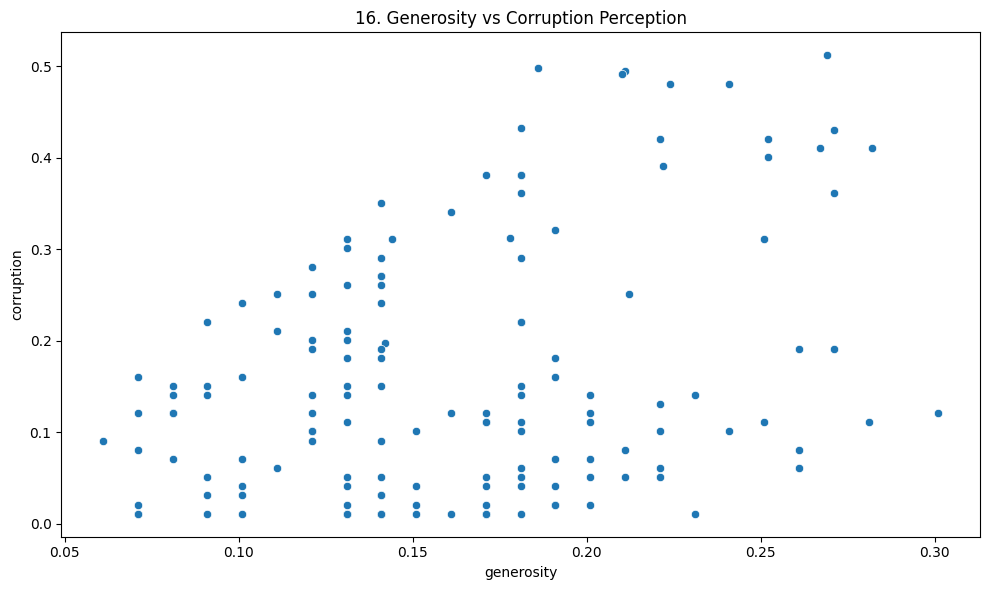

In [28]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='generosity', y='corruption', data=df)
plt.title(f'{plot_no}. Generosity vs Corruption Perception')
show_fig()
plot_no += 1

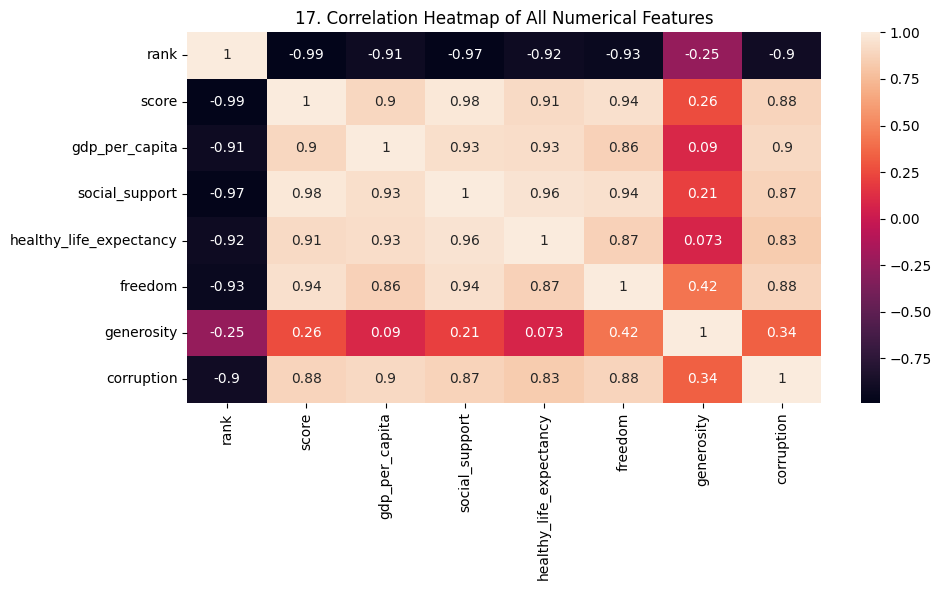

In [29]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include=['float64','int64']).corr()
sns.heatmap(corr, annot=True)
plt.title(f'{plot_no}. Correlation Heatmap of All Numerical Features')
show_fig()
plot_no += 1

# Model Training

## define features and target

In [30]:
X = df[['gdp_per_capita','social_support','healthy_life_expectancy','freedom','generosity','corruption']]
y = df['score']

## split the dataset

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## apply scaling

In [32]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## train the model

In [33]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## make predictions

In [34]:
y_pred = model.predict(X_test)

## print model accuracy

In [35]:
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.9764611047553172


## plot actual vs predicted

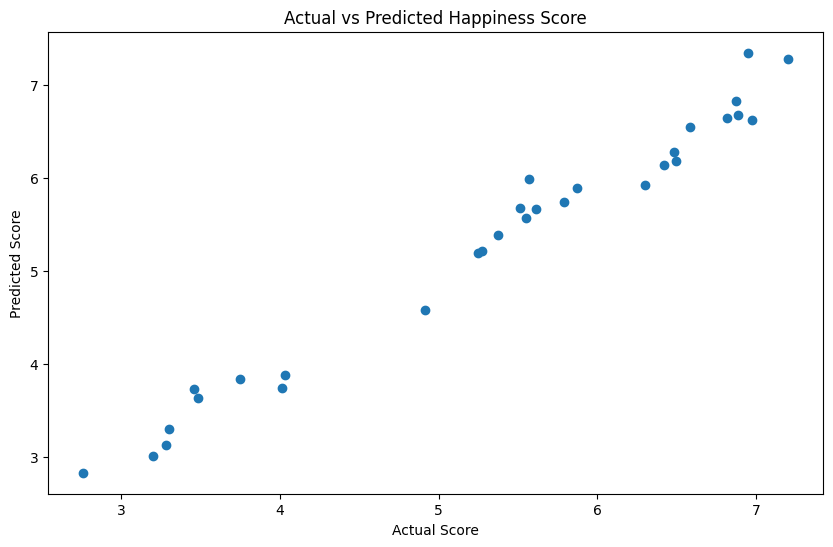

In [36]:
fig = plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Happiness Score")
plt.show()